# Johdanto

Tutustuttiin Transformer-pohjaiseenn kielimalliin:

Koulutettiin tekstigeneraattorin tokenisaattori suomenkielisellä aineistolla käyttäen SentencePiece-kirjastoa.

Tavoitteena oli ymmärtää, miten tekstiaineisto esikäsitellään, miten tokenisaattori toimii ja kuinka eri kokoiset Transformer-mallit vaikuttavat puheentunnistuksen tarkkuuteen.

Ladattiin sentencepiece, spm:nä. Sen tarkoitus on jakaa teksti pienempiin osiin, jotka ovat helpommin käsiteltäviä. Tämä on erityisen tärkeää suomenkielisessä tekstissä, jossa sanojen taivutusmuodot voivat olla monimutkaisempia kuin monissa muissa kielissä.

In [4]:
# Cell 1: Setup and imports
import os

os.environ['KERAS_BACKEND'] = 'tensorflow'  # You can change to 'jax' or 'torch' if preferred

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

Keras version: 3.9.0
Keras backend: tensorflow


Ladataan datasetti, käyttäen r eli read mode, jotta saadaan kaikki merkit oikein. Varmistetaan että käytetään utf-8 enkoodia, jotta saadaan kaikki merkit oikein. Säilytetään datasetti muuttujaan text.

In [5]:
# Cell 2: Load and prepare text data
# Load the Kalevala text
with open('../datasets/seitsemänveljestä.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()  #.lower()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 646563 characters
First 100 characters: The Project Gutenberg eBook of Seitsemän veljestä
    
This ebook is for the use of anyone anywhere 


Luodaan temp_file, jotta voimme säilyttää koko datasetin tekstitiedostona, pelkkänä tekstinä, jotta voimme valmistaa tiedoston SentencePiece koulutusta varten. 

Käytämme spm:n train-funktiota, joka kouluttaa SentencePiece mallin käyttäen temp_file.

Tallennamme model_prefix muuttujaan, jotta voimme käyttää sitä myöhemmin mallin lataamiseen.

Asetetaan vocab_size 40000, joka on hyvä koko suomenkieliselle datasetille, jossa on paljon erilaisia sanoja ja taivutusmuotoja sekä erikoismerkkejä.

Käytetään character_coverage=1.0, jotta saadaan kaikki merkit mukaan. Tämä on tärkeää suomenkielisessä tekstissä, jossa on paljon erikoismerkkejä ja ääkkösiä.

Käytämme model_type='bpe', joka on on Byte Pair Encoding, joka on hyvä malli suomenkieliselle tekstille, koska se on kompromissi merkki- ja sanatasoisen tokenisaation välillä – se pilkkoo sanat osiin, mutta säilyttää yleisimmät yhdistelmät yhtenäisinä yksiköinä. 

Mahdollistaa omien symbolien lisäämisen, kuten <PAD> (täyte) ja <UNK> (tuntematon sana). Näitä käytetään usein mallin erityistarpeisiin, kuten sekvenssien täyttämiseen tai tuntemattomien sanojen käsittelyyn.

sp = spm.SentencePieceProcessor(), Luodaan tokenisaattoriprosessorin instanssin. Koulutuksen jälkeen tätä objektia voidaan käyttää tekstin tokenisointiin, tokenien purkamiseen ja muuhun.

sp.load(f"{model_prefix}.model") Lataa koulutetun SentencePiece-mallin .model-tiedostosta. Nyt sp:ää voidaan käyttää tekstin koodaamiseen tai purkamiseen.

test_text = "Huikea liuta. Tulispa sinusta oikein kukkomaakari" Tarkoitus: Testimerkkijono, jolla nähdään, miten tokenisaattori toimii suomen kielellä.

Lopuksi printataan tokenisoitu esimerkki, jotta nähdään, miten tokenisaattori toimii.


In [6]:
# Cell 3: Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'seitsemänveljestä_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

# Train SentencePiece model
vocab_size = 40000  # You can adjust this based on your needs
model_prefix = 'seitsemänveljestä_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,  # Important for Finnish
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

# Test tokenization
test_text = "Huikea liuta. Tulispa sinusta oikein kukkomaakari"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁Huikea', '▁liuta', '.', '▁Tulispa', '▁sinusta', '▁oikein', '▁kukkomaakari']
Vocabulary size: 40000


Asetetaan seq_length 64, eli seknvenssin pituus

pieces = sp.encode_as_ids(text) Tokenisoidaan teksti BPE-muotoon (muutetaan sanat numeroiksi, eli ID:iksi)

sequences = [] Luodaan tyhjät listat, joihin tallennetaan sekvenssit

for i in range(0, len(pieces) - seq_length): Luodaan sekvenssit, jotka ovat pituudeltaan seq_length. Käytetään len(pieces) - seq_length, jotta saadaan kaikki tokenit mukaan, sekä  Käydään koko tekstiä läpi ja otetaan liukuvalla ikkunalla 65 tokenin mittaisia pätkiä. Ensimmäiset 64 tokenia toimivat syötteenä (input) Viimeinen (65.) token toimii kohteena (target), jonka mallin pitäisi ennustaa

sequences = np.array(sequences) Muutetaan sekvenssit NumPy-taulukoksi, nopeaa laskentaa varten. Erotetaan syötteet (inputs) ja kohteet (targets).

Jaetaan data koulutukseen ja validointiin (80% / 20%) Luodaan satunnaistettu lista indekseistä, jolla datan järjestystä sekoitetaan. Erotellaan lopulliset train_inputs, train_targets, val_inputs, val_targets.

In [7]:
# Cell 4: Prepare training data
# Tokenize the text
seq_length = 64
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

# Create sequences
sequences = []
for i in range(0, len(pieces) - seq_length):
    # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
    sequences.append(pieces[i:i + seq_length + 1])

# Convert to NumPy arrays
sequences = np.array(sequences)
inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 106938
Number of sequences: 106874
Input shape: (106874, 64)
Target shape: (106874, 64)


Paikkatietoenkoodaus: Paikkatieto lisätään tokenien upotuksiin, jotta malli ymmärtää tokenien järjestyksen syötteessä. Tämä tehdään sinus- ja kosinifunktioilla, jotka muuntavat sekvenssin paikat vektoreiksi. Tarkoitus: Paikkatietoenkoodaukset lisätään upotuksiin (embeddings) säilyttämään tietoa tokenien järjestyksestä syötteessä, koska Transformer-malli ei itse käsittele sekventiaalista järjestystä. positions: Luo taulukon, joka edustaa positiota sekvenssissä (0:sta max_len-1 asti). angles: Määrittelee, miten positiot vuorovaikuttavat d_model-arvon kanssa (upotuksen dimensio). Käytetään sinus- ja kosinifunktioita, jotka enkoodaavat paikan. Sinusoidiset funktiot valitaan, koska ne auttavat mallia yleistämään eri pituisille sekvensseille. Tämä enkoodaus lisätään tokenien upotuksiin, jolloin saadaan sekvenssi, jossa on sekä tokenin että sen paikan tieto.

Syötekerros ja Upotukset: Syöte koostuu tokenien indekseistä, jotka muunnetaan 256-ulotteisiksi upotuksiksi Embedding-kerroksessa. Paikkatietoenkoodaus lisätään upotuksiin. num_heads = 4: Huomio-otsikoiden määrä monipäisessä huomiossa. Tämä auttaa mallia keskittymään eri osiin syötettä samanaikaisesti. ff_dim = 512: Syväverkon (feed-forward network) dimensio joka Transformer-kerroksessa. num_layers = 3: Transformer-kerrosten määrä (jokainen kerros koostuu monipäisestä huomiosta ja syväverkosta).

Kausaalimaski: Luodaan kausaalimaski, joka estää mallia katsomasta tulevia tokeneita. Tämä on tärkeää, erityisesti tekstin generoinnissa, jotta malli ennustaa tokenit oikeassa järjestyksessä.

Transformer-kerrokset: Malli sisältää useita Transformer-kerroksia, jotka koostuvat monipäisestä huomiosta (multi-head attention) ja syväverkoista (feed-forward networks).

Monipäinen huomio antaa mallille mahdollisuuden tarkastella syötteen eri osia samanaikaisesti.

Syväverkko (FFN) oppii monimutkaisempia suhteita ja muunnoksia.

Lopullinen ulostulo: Malli päätyy tiheään kerrokseen, joka ennustaa seuraavan tokenin sekvenssissä. Tämä mahdollistaa tekstin luomisen tai sekvenssin ennustamisen.

Kokoaminen: Malli koulutetaan Adam-optimoijalla ja harvojen kategoristen ristivirheiden häviöfunktiolla. Malli optimoi parametrejaan käyttäen näitä työkaluja.

In [8]:
# Cell 5: Define the model
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000 ** angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding


# Define model parameters
embed_dim = 256
num_heads = 4
ff_dim = 512
num_layers = 3

# Create the model
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding


# Helper function to create causal attention mask
def create_causal_mask(size):
    """Create a causal attention mask to prevent looking at future tokens."""
    mask = 1 - np.triu(np.ones((size, size)), k=1)
    return mask  # Lower triangular matrix


# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    # Manually create causal mask since use_causal_mask parameter isn't available
    causal_mask = create_causal_mask(seq_length)

    # Apply attention with manual causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads
    )(x, x, attention_mask=causal_mask)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1744813228.918548    1823 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 256)   │ 10,240,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 64, 256)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_1 (Cast)       │ (None, 64, 256)   │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ cast[0][0],       │
│ (MultiHeadAttentio… │                   │            │ cast_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 256)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 256)   │        512 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ layer_normalizat

 Total params: 22,101,312 (84.31 MB)

 Trainable params: 22,101,312 (84.31 MB)

 Non-trainable params: 0 (0.00 B)

batch_size = 64, epochs = 20, koulutetaan malli käyttäen Callback -funktioita, jotka auttavat optimoimaan koulutusprosessia, sekä earlystopping joka pysäyttää koulutuksen, jos validointivirhe ei parane kolmen epookin ajan (patience=3), ja palauttaa mallin parhaat painot. ReduceLROnPlateau pienentää oppimisnopeutta, jos validointivirhe ei parane yhden epookin aikana (patience=1), mikä voi auttaa mallia löytämään paremman optimointiratkaisun. ModelCheckpoint tallentaa mallin parhaat painot tiedostoon kalevala_best_model.keras aina, kun mallin suorituskyky paranee validointidatalla.

In [9]:
# Cell 6: Train the model
batch_size = 64
epochs = 20

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('kalevala_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/20


I0000 00:00:1744813235.474483    1982 service.cc:152] XLA service 0x7f13a0001f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744813235.474510    1982 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2025-04-16 14:20:35.663189: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-16 14:20:36.092330: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
I0000 00:00:1744813236.567190    1982 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-04-16 14:20:38.572369: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_85', 432 bytes spill stores,

1334/1336 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1212 - loss: 7.4086

2025-04-16 14:21:40.085379: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-04-16 14:21:41.899519: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 3224 bytes spill stores, 3232 bytes spill loads

2025-04-16 14:21:41.977933: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_85', 428 bytes spill stores, 340 bytes spill loads

2025-04-16 14:21:42.039110: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_85', 432 bytes spill stores, 344 bytes spill loads

2025-04-16 14:21:42.312752: I external/local_xla/xla/stream_ex

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1213 - loss: 7.4069

2025-04-16 14:21:58.898848: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-04-16 14:22:04.166597: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/assert_equal_1/Assert/Assert
2025-04-16 14:22:05.482949: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_26', 108 bytes spill stores, 116 bytes spill loads

2025-04-16 14:22:05.784427: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_7', 104 bytes spill stores, 104 bytes spill loads

2025-04-16 14:22:05.818404: I external/local_xla/xla/stream_executor/cuda/subprocess_co

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 99s 57ms/step - accuracy: 0.1214 - loss: 7.4060 - val_accuracy: 0.3140 - val_loss: 4.2082 - learning_rate: 3.0000e-04
Epoch 2/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 54s 40ms/step - accuracy: 0.4622 - loss: 3.1734 - val_accuracy: 0.8914 - val_loss: 0.6283 - learning_rate: 3.0000e-04
Epoch 3/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 52s 39ms/step - accuracy: 0.9175 - loss: 0.4928 - val_accuracy: 0.9630 - val_loss: 0.2113 - learning_rate: 3.0000e-04
Epoch 4/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - accuracy: 0.9647 - loss: 0.2010 - val_accuracy: 0.9684 - val_loss: 0.1691 - learning_rate: 3.0000e-04
Epoch 5/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 53s 40ms/step - accuracy: 0.9710 - loss: 0.1530 - val_accuracy: 0.9703 - val_loss: 0.1555 - learning_rate: 3.0000e-04
Epoch 6/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 53s 40ms/step - accuracy: 0.9739 - loss: 0.1325 - val_accuracy: 0.9722 - val_loss: 0.1455 - learning_rate: 3.0000e-04
Epoch 7/20
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/

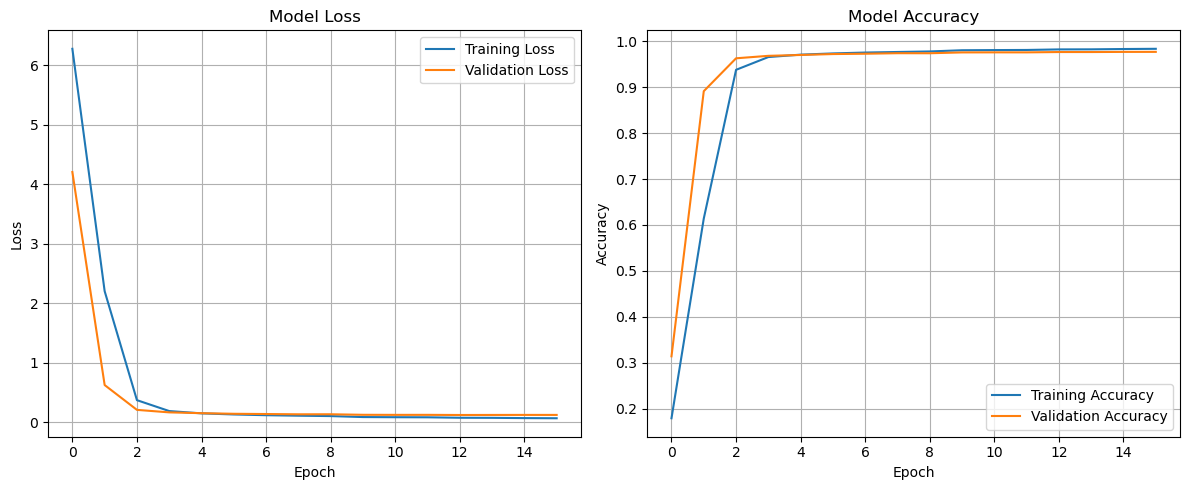

In [10]:
# Cell 7: Plot training metrics
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [11]:
# Cell 8: Save the model
model.save('seitsemänveljestä_model.keras')
print("Model saved as 'seitsemänveljestä_model.keras'")

Model saved as 'seitsemänveljestä_model.keras'


Tämä funktio luo tekstiä mallin avulla annetun syötteen (promptin) pohjalta. Se toimii seuraavasti:

Syötteen käsittely: Syöte muutetaan pieniksi kirjaimiksi (tätä osaa ei käytetä, mutta se varmistaisi, että syöte vastaa koulutusdataa), ja se koodataan mallin ymmärtämäksi token-sekvenssiksi.

Syötteen pituus: Jos syöte on liian lyhyt, se täydennetään nollilla, mutta jos se on liian pitkä, otetaan vain viimeiset seq_length tokenia.

Tekstin generointi: Malli ennustaa seuraavat tokenit yksi kerrallaan, ja seuraava token valitaan todennäköisyyksien perusteella, joita säädetään lämpötilalla. Korkeampi lämpötila tekee tekstistä satunnaisempaa ja luovempaa.

Lopputulos: Kun haluttu määrä tokenia on generoitu, ne dekoodataan takaisin luettavaksi tekstiksi.

Periaatteessa, tämä funktio ottaa syötteen, luo siitä tekstiä mallin avulla ja palauttaa luonnollisesti kuuluvan tekstin, jota voi käyttää mihin tahansa tarpeeseen.

In [12]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """Generate text based on a prompt with proper lowercase handling."""
    # Convert prompt to lowercase to match training data
    lowercase_prompt = prompt  #.lower()

    # Encode the prompt
    input_ids = sp.encode_as_ids(lowercase_prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

Tekstin generointi: Koodissa on for-looppi, joka käy läpi kaikki syötteet. Jokaiselle syötteelle funktio generate_text kutsutaan ja se luo 100 tokenia pitkän tekstin. temperature on asetettu arvoon 1.2, mikä tarkoittaa, että mallin teksti on luovempaa ja satunnaisempaa.

Tulostus: Generoidun tekstin lisäksi tulostetaan myös alkuperäinen syöte, jotta voi vertailla sitä siihen, miten malli on jatkanut tekstiä.

Syötteet kuten "Helvetti," ja "Mutta yön lepoon läksivät" antavat alkupisteen, ja malli jatkaa tekstiä luoden uusia lauseita tai virkkeiden osia, jotka liittyvät annettuun alkuun.

Koodi tulostaa alkuperäiset syötteet ja niiden perään generoidut tekstit, jolloin voit tarkastella, kuinka malli jatkaa tekstin luomista.

Testataan ensin tekstin generointi default parametreilla, eli 100 tokenia ja lämpötila 1.0.

In [35]:
# Cell 10: Generate sample text
prompts = [
    "Helvetti",
    "Mutta yön lepoon",
]


def generate_text_for_prompts(prompts, num_tokens, temperature):
    for prompt in prompts:
        print(f"\nPrompt: {prompt}")
        generated = generate_text(model, sp, prompt, num_tokens, temperature)
        print(generated)

generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=1.0)


Prompt: Helvetti
Helvetti tupaan, jos hän, tullessa on emäntä on talon kirkas aurinko, joka valaisee ja lämmittää.--Katso: ensimmäisenä jättää hän aamulla vuoteen, sotkee taikinansa, rakentaa miehellensä suurusta pöytään, evästää heidän metsään ja siitä kiirehtii hän kiulu kourassa tarhaan, lypsämään kirjavan karjansa. Nyt hän leipoo, hyörii ja pyörii; nyt on hän pöydän ääressä, nyt keikahtaa hän tuolla peräpenkin päässä leipä kämmenillä, ja nyt hän pyrynä kohentelee uunia, joka ammentaa hohtavasta kidastansa tulta ja savua. Nyt hän, leipäin noustessa, viimein itsekin, lapsi rinnoilla, einehtii

Prompt: Mutta yön lepoon
Mutta yön lepoon seuraavaksi kevääksi ja riensivät hankkimaan muonaa niin elikoille kuin itsellensä. Syksyn koleissa metsissä he kaalailivat ristiin, rastiin koirinensa, tehden veristä niitosta; ja alas suon rannalle kohosi taasen korkea heinäsuova vanhaa Valkoa varten. Talvi oli tullut; joulu-aattona palasi Eero kotia, jahtivoudin mielestä tarpeeksi oppineena ja kelvo

Muutetaan ensin lämpötilaa, mikä vaikuttaa tekstin satunnaisuuteen. Mitä pienempi lämpötila sitä loogisempaa teksti on, mutta myös vähemmän luovaa. Mitä suurempi lämpötila, sitä satunnaisempaa ja luovempaa teksti on, mutta myös vähemmän järkevää.

In [36]:
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=0.2)


Prompt: Helvetti
Helvetti valmis, että hän oikein rupeaa naukuilemaan tuossa mahassa? JUHANI. Se naukuilee ensi-ajan maarussamme, mutta sieltä ampuu se pian tuohon pamppailevaan sydämeen, ampuu kuin kissa lihavan hiiren niskaan, ja silloin lannistuu uhkea mies. Kova, kova on nyt miehen päivä. Mihin keinoon käymme? kysyn minäkin. AAPO. Huutakaamme huikeasti kaikki yhdestä suusta; äänen ehkä kuulee jokin metsässä käyskelevä, tai ehtii se aina Viertolaan ja saattaa ihmiset jotain arvelemaan. JUHANI. Sitä keinoa käy koettaa. TIMO. Huutakaamme vahvasti. JUHANI. Oikein riivatusti. Paukahtakaamme

Prompt: Mutta yön lepoon
Mutta yön lepoon seuraavaksi kevääksi ja riensivät hankkimaan muonaa niin elikoille kuin itsellensä. Syksyn koleissa metsissä he kaalailivat ristiin, rastiin koirinensa, tehden veristä niitosta; ja alas suon rannalle kohosi taasen korkea heinäsuova vanhaa Valkoa varten. Talvi oli tullut; joulu-aattona palasi Eero kotia, jahtivoudin mielestä tarpeeksi oppineena ja kelvollisn

Kuten ylhäältä näemme, lämpötilan laskeminen 0.2:een tekee tekstistä paljon järkevämpää ja vähemmän satunnaista. Tekstissä on kuitenkin paljon suoria kopioita alkuperäisestä tekstistä.

Seuraavaksi testataan korkealla lämpötilalla.

In [37]:
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=2.0)


Prompt: Helvetti
Helvetti samoin hetki, koska hän vähemmin, jota itse lappasi hiki hänen povestansa hänen silmäkuoppiinsa synkeän sanottu uhkean laukkaa sen ylitse; ja ylify, ja pian hyrisi itkussa hänkin, ja Aaponkin silmistä säteili nurkkiin, saattaen jälkensä nöyrtyvät. TIMO. Metsässäcontact kahila, siinähän povensa tähti hikeä. EERO. Ja puhaltaen niinkuin kitaa itse, niin on tieltä kotkanhäntä, niin katso: varsinkin niin tapahtuu se tuumiskeli Rukoillaan kaikki kuuluttaa esimerkin: olenpa Sammale makaa Siellä hallitsi syntyy niellä täällä antakoon jumisevalle pihalle, komeroisen vuoren alle. Toinen tuli kuin Toisesta sarvesta

Prompt: Mutta yön lepoon
Mutta yön lepoon tiennyt. rakastajanettavaksi on koita ja kitsaammaksi kävi se aina tappelus villaisten penikkain ja rohkean äkeä ja tilhiparvi merkillinen tarina, jota hän haasteli tavallisiin toimiinsa Jukolan talossa.--Niinpä siivo Simeoni, koskaan enään lasia kallistamatta, vietti ikänsä pimeät päivät Jukolan talossa hirveä matoi

Nyt teksti alkaa olla jo epäloogista, eikä siitä löydy juurikaan järkeviä virkkeitä.

In [14]:
# Cell 11: Load model (if you're starting a new session)
# Uncomment these lines to load a previously saved model
"""
# Load saved model
model = keras.models.load_model('kalevala_model.keras')

# Load SentencePiece tokenizer
sp = spm.SentencePieceProcessor()
sp.load('kalevala_sp.model')

# Test generation
prompt = "Mieleni minun tekevi"
generated = generate_text(model, sp, prompt, num_tokens=150, temperature=1.0)
print(generated)
"""

'\n# Load saved model\nmodel = keras.models.load_model(\'kalevala_model.keras\')\n\n# Load SentencePiece tokenizer\nsp = spm.SentencePieceProcessor()\nsp.load(\'kalevala_sp.model\')\n\n# Test generation\nprompt = "Mieleni minun tekevi"\ngenerated = generate_text(model, sp, prompt, num_tokens=150, temperature=1.0)\nprint(generated)\n'